 Install packages (run once per fresh session)
*italicised text*

---




In [ ]:
# Run this first cell in Colab
!pip install --quiet nltk kagglehub scikit-learn matplotlib

In [ ]:
import os, glob, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import kagglehub


In [ ]:
# Download dataset (adjust id string if needed)
path = kagglehub.dataset_download("anandshaw2001/video-game-sales")
print("Dataset path:", path)

# find csv(s)
csvs = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)
print("Found CSV files:", csvs)

# load the first csv found
if not csvs:
    raise RuntimeError("No CSV found in dataset path. Upload CSV manually if needed.")
csv_path = csvs[0]
print("Loading CSV:", csv_path)
df = pd.read_csv(csv_path, encoding='utf-8', on_bad_lines='skip', dtype=str)  # read as str first
print("Raw shape:", df.shape)
df.head()


100%|██████████| 381k/381k [00:00<00:00, 1.02MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/anandshaw2001/video-game-sales/versions/1
Found CSV files: ['/root/.cache/kagglehub/datasets/anandshaw2001/video-game-sales/versions/1/vgsales.csv']
Loading CSV: /root/.cache/kagglehub/datasets/anandshaw2001/video-game-sales/versions/1/vgsales.csv
Raw shape: (16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1,31.37


In [ ]:
# Preview columns and a short summary
print("Columns:", df.columns.tolist())
df_sample = df.copy()

# Convert common numeric columns to numeric (errors -> NaN)
num_cols = []
for c in df_sample.columns:
    # common names in video game sales dataset: 'Global_Sales','EU_Sales','JP_Sales','NA_Sales','Year_of_Release','Critic_Score','User_Score'
    if any(k in c.lower() for k in ['sales','year','score','count','rating','units']):
        try:
            df_sample[c] = pd.to_numeric(df_sample[c].str.replace(',', '').str.strip(), errors='coerce')
            num_cols.append(c)
        except Exception:
            pass

print("Converted numeric-like columns:", num_cols)
display(df_sample.head())
display(df_sample.info())


Columns: ['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
Converted numeric-like columns: ['Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  object 
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


None

In [ ]:
# Preview columns and a short summary
print("Columns:", df.columns.tolist())
df_sample = df.copy()

# Convert common numeric columns to numeric (errors -> NaN)
num_cols = []
for c in df_sample.columns:
    # common names in video game sales dataset: 'Global_Sales','EU_Sales','JP_Sales','NA_Sales','Year_of_Release','Critic_Score','User_Score'
    if any(k in c.lower() for k in ['sales','year','score','count','rating','units']):
        try:
            df_sample[c] = pd.to_numeric(df_sample[c].str.replace(',', '').str.strip(), errors='coerce')
            num_cols.append(c)
        except Exception:
            pass

print("Converted numeric-like columns:", num_cols)
display(df_sample.head())
display(df_sample.info())


Columns: ['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
Converted numeric-like columns: ['Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  object 
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


None

In [ ]:
# For sales forecasting choose a target. Video game dataset commonly has 'Global_Sales' (rename variations if needed).
# Inspect possible target column names
candidates = [c for c in df_sample.columns if 'global' in c.lower() or 'total' in c.lower()]
print("Potential target columns:", candidates)

# If 'Global_Sales' exists use it, otherwise pick first candidate
target_col = None
if 'Global_Sales' in df_sample.columns:
    target_col = 'Global_Sales'
elif candidates:
    target_col = candidates[0]
else:
    # fallback: try exact matches case-insensitive
    for c in df_sample.columns:
        if c.lower() == 'global_sales' or c.lower() == 'globalsales':
            target_col = c
            break

if target_col is None:
    raise RuntimeError("Couldn't detect target column like Global_Sales. Inspect df.columns and set target_col manually.")

print("Using target:", target_col)
# Basic cleaning: drop rows missing target
df_model = df_sample.copy()
df_model[target_col] = pd.to_numeric(df_model[target_col], errors='coerce')
df_model = df_model.dropna(subset=[target_col]).reset_index(drop=True)
print("After dropping target-NaNs shape:", df_model.shape)


Potential target columns: ['Global_Sales']
Using target: Global_Sales
After dropping target-NaNs shape: (16598, 11)


In [ ]:
# Example features: Year_of_Release, Platform, Genre, Publisher, NA_Sales, EU_Sales, JP_Sales, Other_Sales
# Identify these columns if present (case-insensitive)
col_map = { 'year':'year', 'platform':'platform', 'genre':'genre', 'publisher':'publisher',
            'na_sales':'na_sales', 'eu_sales':'eu_sales', 'jp_sales':'jp_sales', 'other_sales':'other_sales' }

found = {}
for orig, key in col_map.items():
    for c in df_model.columns:
        if orig in c.lower().replace(' ','_'):
            found[key] = c
            break

print("Found mappings:", found)

# Convert known numeric sales columns to numeric if present
for k in ['na_sales','eu_sales','jp_sales','other_sales']:
    if k in found:
        df_model[found[k]] = pd.to_numeric(df_model[found[k]].astype(str).str.replace(',',''), errors='coerce')

# Year as numeric
if 'year' in found:
    df_model[found['year']] = pd.to_numeric(df_model[found['year']], errors='coerce')

# Create simple derived features
# 1) total_regional_sales = NA + EU + JP + Other (if present separately)
reg_cols = [found[k] for k in ['na_sales','eu_sales','jp_sales','other_sales'] if k in found]
if reg_cols:
    df_model['regional_sum'] = df_model[reg_cols].sum(axis=1, skipna=True)

# 2) title length (if 'Name' or similar exists)
name_col = None
for c in df_model.columns:
    if 'name' in c.lower() or 'title' in c.lower():
        name_col = c
        break
if name_col:
    df_model['title_len'] = df_model[name_col].astype(str).apply(len)

# Keep a shortlist of features
print("Sample engineered columns:", [c for c in df_model.columns if c in ['regional_sum','title_len']])
display(df_model[[target_col] + reg_cols + (['regional_sum','title_len'] if 'regional_sum' in df_model.columns else [])].head())


Found mappings: {'year': 'Year', 'platform': 'Platform', 'genre': 'Genre', 'publisher': 'Publisher', 'na_sales': 'NA_Sales', 'eu_sales': 'EU_Sales', 'jp_sales': 'JP_Sales', 'other_sales': 'Other_Sales'}
Sample engineered columns: ['regional_sum', 'title_len']


,Global_Sales,NA_Sales,EU_Sales,JP_Sales,Other_Sales,regional_sum,title_len
0,82.74,41.49,29.02,3.77,8.46,82.74,10
1,40.24,29.08,3.58,6.81,0.77,40.24,17
2,35.82,15.85,12.88,3.79,3.31,35.83,14
3,33.00,15.75,11.01,3.28,2.96,33.00,17
4,31.37,11.27,8.89,10.22,1.00,31.38,24


In [ ]:
# Select predictors - include numeric fields and some categorical encodings
# Start with numeric columns we have
predictors = []

# Add year if present
if 'year' in found:
    predictors.append(found['year'])
# Add regional_sum if present
if 'regional_sum' in df_model.columns:
    predictors.append('regional_sum')
# Add title_len if present
if 'title_len' in df_model.columns:
    predictors.append('title_len')
# Add any per-region sales if present (you might want to remove these if forecasting global from history)
predictors += reg_cols

# For categorical columns like platform, genre, publisher — we will one-hot a limited number (top N) to avoid explosion
categorical_cols = []
for key in ['platform','genre','publisher']:
    if key in found:
        categorical_cols.append(found[key])

# limit publisher to top 20 to avoid too many dummies
df_tmp = df_model.copy()
for cat in categorical_cols:
    df_tmp[cat] = df_tmp[cat].fillna('Unknown').astype(str)

# Build final feature matrix using one-hot for small cats (platform, genre) and top-k for publisher
X = df_tmp[predictors].copy() if predictors else pd.DataFrame(index=df_tmp.index)
# one-hot platform and genre
for cat in categorical_cols:
    if cat in df_tmp.columns:
        top_vals = df_tmp[cat].value_counts().nlargest(20).index.tolist()
        for val in top_vals:
            X[f"{cat}_{val}"] = (df_tmp[cat] == val).astype(int)

# fill numeric NaNs with 0 (or median for better practice)
X = X.fillna(0)
y = df_tmp[target_col].astype(float).fillna(0)

print("Final X shape:", X.shape, "y shape:", y.shape)
display(X.head())


Final X shape: (16598, 59) y shape: (16598,)


,Year,regional_sum,title_len,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Platform_DS,Platform_PS2,Platform_PS3,...,Publisher_Capcom,Publisher_Atari,Publisher_Tecmo Koei,Publisher_Unknown,Publisher_Square Enix,Publisher_Warner Bros. Interactive Entertainment,Publisher_Disney Interactive Studios,Publisher_Eidos Interactive,Publisher_Midway Games,Publisher_505 Games
0,2006.0,82.74,10,41.49,29.02,3.77,8.46,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1985.0,40.24,17,29.08,3.58,6.81,0.77,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2008.0,35.83,14,15.85,12.88,3.79,3.31,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2009.0,33.00,17,15.75,11.01,3.28,2.96,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1996.0,31.38,24,11.27,8.89,10.22,1.00,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Use a simple random split. For time-series you would use time-based split — video game dataset may not be time-series per product.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (13278, 59) Test shape: (3320, 59)


In [ ]:
# 1) Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# 2) Decision Tree
dt = DecisionTreeRegressor(random_state=42, max_depth=8)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# 3) Random Forest (baseline)
rf = RandomForestRegressor(random_state=42, n_estimators=100, max_depth=12, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


Linear Regression: {'MAE': 0.0030274298134341936, 'RMSE': np.float64(0.0052349682007290285), 'R2': 0.999993477144038}
Decision Tree     : {'MAE': 0.022412754908895882, 'RMSE': np.float64(0.8159054877265498), 'R2': 0.8415510370836482}
Random Forest     : {'MAE': 0.02025379351431613, 'RMSE': np.float64(0.8228938267226718), 'R2': 0.8388251401558449}


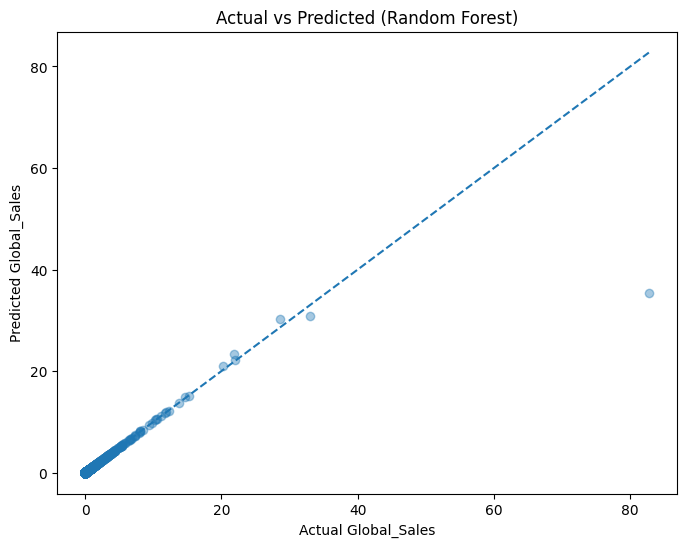

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

def evaluate(y_true, y_pred):
    # ensure numeric arrays
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)     # returns MSE (no 'squared' arg in older sklearn)
    rmse = np.sqrt(mse)                          # compute RMSE manually
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

# Convert y_test and preds to numeric arrays (safe)
y_test_np = np.asarray(y_test, dtype=float)
lr_pred_np = np.asarray(lr_pred, dtype=float)
dt_pred_np = np.asarray(dt_pred, dtype=float)
rf_pred_np = np.asarray(rf_pred, dtype=float)

print("Linear Regression:", evaluate(y_test_np, lr_pred_np))
print("Decision Tree     :", evaluate(y_test_np, dt_pred_np))
print("Random Forest     :", evaluate(y_test_np, rf_pred_np))

# Plot actual vs predicted for Random Forest
plt.figure(figsize=(8,6))
plt.scatter(y_test_np, rf_pred_np, alpha=0.4)
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], linestyle='--')
plt.xlabel('Actual ' + str(target_col))
plt.ylabel('Predicted ' + str(target_col))
plt.title('Actual vs Predicted (Random Forest)')
plt.show()


In [ ]:
# Warning: this can be slow. Reduce param grid for speed or use RandomizedSearchCV.
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [8, 12, None],
    'min_samples_split': [2, 5]
}
rf_gs = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), param_grid, cv=3, scoring='neg_root_mean_squared_error', verbose=1)
rf_gs.fit(X_train, y_train)
print("Best params:", rf_gs.best_params_)
best_rf = rf_gs.best_estimator_
best_pred = best_rf.predict(X_test)
print("Best RF eval:", evaluate(y_test, best_pred))


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best RF eval: {'MAE': 0.02040076176133104, 'RMSE': np.float64(0.8184438171242281), 'R2': 0.8405636156391284}


regional_sum                             9.916359e-01
NA_Sales                                 6.555278e-03
JP_Sales                                 4.289355e-04
title_len                                2.943247e-04
Other_Sales                              2.212712e-04
Genre_Platform                           1.980798e-04
EU_Sales                                 1.843751e-04
Year                                     1.719097e-04
Genre_Racing                             6.564195e-05
Platform_Wii                             4.414071e-05
Genre_Shooter                            4.327375e-05
Genre_Puzzle                             3.327513e-05
Platform_DS                              2.655296e-05
Publisher_Take-Two Interactive           1.997890e-05
Genre_Role-Playing                       1.658987e-05
Publisher_Nintendo                       1.613200e-05
Genre_Simulation                         1.496267e-05
Genre_Action                             8.340215e-06
Platform_PS2                

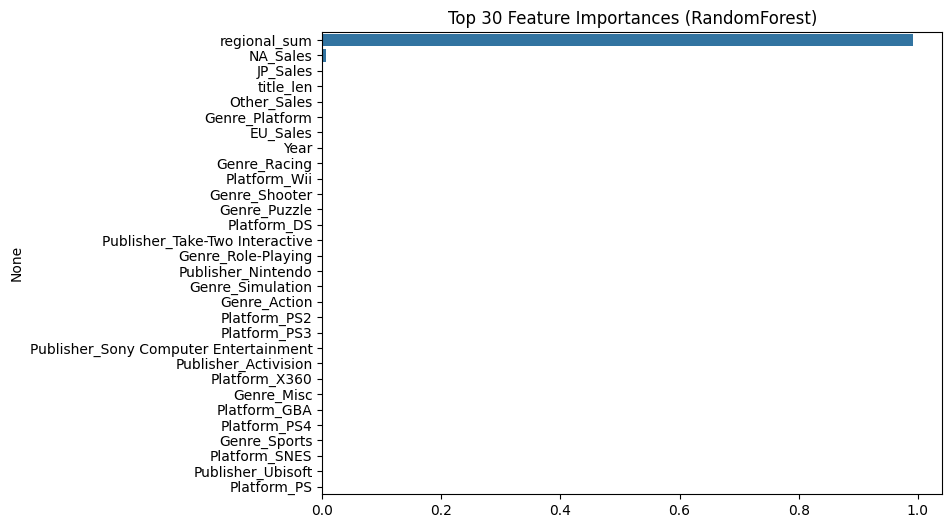

In [ ]:
if hasattr(rf, "feature_importances_"):
    fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(30)
    print(fi)
    plt.figure(figsize=(8,6))
    sns.barplot(x=fi.values, y=fi.index)
    plt.title("Top 30 Feature Importances (RandomForest)")
    plt.show()
else:
    print("Model has no feature_importances_ attribute.")


In [ ]:
# Save the trained RandomForest model
model_path = "/content/rf_sales_model.joblib"
joblib.dump(rf, model_path)
print("Saved model to", model_path)

# Save processed dataset used for modeling
processed_path = "/content/processed_sales_data.csv"
pd.concat([X, y.rename(target_col)], axis=1).to_csv(processed_path, index=False)
print("Saved processed data to", processed_path)


Saved model to /content/rf_sales_model.joblib
Saved processed data to /content/processed_sales_data.csv
